To implement Principal Component Analysis (PCA) for dimensionality reduction, visualize the
reduced data and evaluate its effectiveness using a classification algorithm.

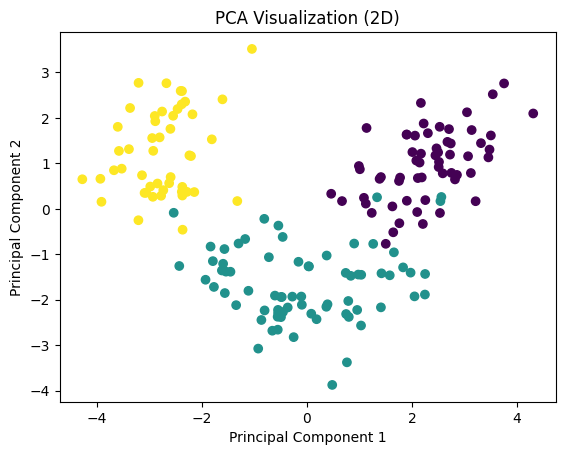

Accuracy BEFORE PCA: 1.0
Accuracy AFTER PCA: 1.0
Explained Variance Ratio: [0.36198848 0.1920749 ]


In [1]:
# ==============================
# 1. Import Libraries
# ==============================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# ==============================
# 2. Load Dataset
# ==============================
data = load_wine()
X = data.data
y = data.target

# ==============================
# 3. Feature Scaling
# ==============================
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ==============================
# 4. Apply PCA (Reduce to 2D)
# ==============================
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# ==============================
# 5. Visualization
# ==============================
plt.figure()
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y)
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA Visualization (2D)")
plt.show()

# ==============================
# 6. Classification BEFORE PCA
# ==============================
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print("Accuracy BEFORE PCA:", accuracy_score(y_test, y_pred))

# ==============================
# 7. Classification AFTER PCA
# ==============================
X_train_pca, X_test_pca, y_train, y_test = train_test_split(X_pca, y, test_size=0.2, random_state=42)

model.fit(X_train_pca, y_train)

y_pred_pca = model.predict(X_test_pca)
print("Accuracy AFTER PCA:", accuracy_score(y_test, y_pred_pca))

# ==============================
# 8. Explained Variance (Important)
# ==============================
print("Explained Variance Ratio:", pca.explained_variance_ratio_)